# Taller: PCA y K-means en salud

## 1. Introducción

El análisis de componentes principales (**PCA, Principal Component Analysis**) y el agrupamiento mediante **K-means clustering** son técnicas de **aprendizaje no supervisado** ampliamente utilizadas en investigación biomédica.
Mientras que PCA permite **reducir la dimensionalidad** de los datos manteniendo la mayor parte de la variabilidad, K-means busca **descubrir patrones ocultos** agrupando a los pacientes según sus características.

En este taller exploraremos estas dos herramientas aplicadas a problemas de salud. Comenzaremos con el dataset de **cáncer de mama ([Breast Cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html))**, donde trabajaremos con un escenario de clasificación binaria, y luego avanzaremos al dataset de **[Diabetes](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_diabetes.html)**, que contiene un resultado clínico continuo asociado a la progresión de la enfermedad.

El objetivo es que aprendas a explorar, reducir y agrupar datos biomédicos, interpretando los resultados tanto desde una perspectiva técnica como clínica. Además, generarás visualizaciones que facilitan la comprensión de estructuras complejas en datasets de salud.


## 2. Objetivos

1. **Carga y estandarización de datos biomédicos**: preparar las variables clínicas para el análisis.
2. **Reducción de dimensionalidad con PCA**: visualizar pacientes en espacios de 2D que preservan la variabilidad más importante.
3. **Clustering con K-means**: identificar posibles subgrupos o fenotipos en los datos.
4. **Evaluación del clustering**: comparar resultados con etiquetas reales (Breast Cancer) o métricas como silhouette (Diabetes).
5. **Visualización de resultados**: generar gráficos en 2D para interpretar los patrones encontrados.
6. **Discusión clínica**: analizar cómo estas técnicas pueden apoyar el diagnóstico, el pronóstico y la investigación en salud.



## 3. Importar librerias

In [37]:
# Librerias generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


## 4. Dataset cáncer de mama

El Breast Cancer Dataset es un conjunto de datos ampliamente utilizado en el aprendizaje automático aplicado a la medicina. Su objetivo es clasificar tumores de mama en dos categorías:

- **M** = maligno  
- **B** = benigno  

### Características principales
- **Número de instancias:** 569  
- **Número de variables:** 30 (numéricas reales)  
- **Variable objetivo:** `Diagnosis` (M/B)  
- **Tarea principal:** Clasificación supervisada  

### Variables
Las características corresponden a medidas de núcleos celulares. Cada una se resume en **media, error estándar y máximo**, resultando en 30 variables en total. Entre ellas destacan:  

- **Radio:** media de distancias desde el centro al perímetro.  
- **Textura:** desviación estándar de los valores en escala de grises.  
- **Perímetro y Área.**  
- **Suavidad:** variación local de radios.  
- **Compacidad:** (perímetro² / área − 1).  
- **Concavidad y puntos cóncavos:** severidad y número de partes cóncavas del contorno.  
- **Simetría.**  
- **Dimensión fractal:** aproximación tipo “línea de costa”.  






#### **Ejercicio 1** 

1. Carga el dataset desde scikit-learn. HINT: puedes utilizar la función `load_breast_cancer`
2. Inspeccióna forma, tipos y valores faltantes
3. Revisar distribución de clases (0=maligno, 1=benigno)
4. Explorar la relación entre las variables mediante una matrix de correlación
5. Responda:
    * ¿Qué indica la alta correlación entre ciertas variables?
    * ¿Qué implicancias tiene para el análisis posterior?


In [38]:
# <CODE> 1. Cargar dataset
from sklearn.datasets import load_breast_cancer
bc = load_breast_cancer()
Y = pd.Series(bc.target, name='target')
X = pd.DataFrame(bc.data, columns=bc.feature_names)

In [39]:
# <CODE> 2. Vistazo general
print("=== Breast Cancer: shape ===")
print("X:", X.shape, " | y:", Y.shape, "\n")

print("=== Tipos de datos (todas numéricas) ===")
print(X.dtypes.value_counts(), "\n")

print("=== Valores faltantes por columna (conteo) ===")
print(X.isna().sum().sort_values(ascending=False).head(10), "\n")

print("=== Filas duplicadas en X ===")
print(X.duplicated().sum(), "\n")



=== Breast Cancer: shape ===
X: (569, 30)  | y: (569,) 

=== Tipos de datos (todas numéricas) ===
float64    30
Name: count, dtype: int64 

=== Valores faltantes por columna (conteo) ===
mean radius               0
mean texture              0
mean perimeter            0
mean area                 0
mean smoothness           0
mean compactness          0
mean concavity            0
mean concave points       0
mean symmetry             0
mean fractal dimension    0
dtype: int64 

=== Filas duplicadas en X ===
0 



=== Distribución de la clase (0=maligno, 1=benigno) ===
target
1    357
0    212
Name: conteo, dtype: int64
target
1    62.74
0    37.26
Name: %, dtype: float64 



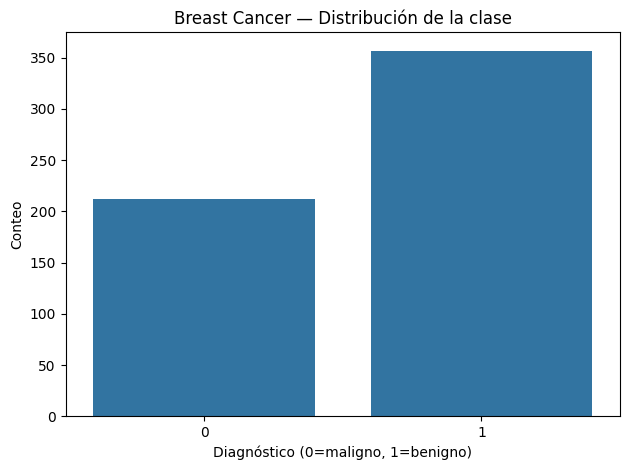

In [40]:
# <CODE> 3 Distribución de la clase
print("=== Distribución de la clase (0=maligno, 1=benigno) ===")
print(Y.value_counts().rename("conteo"))
print((Y.value_counts(normalize=True)*100).round(2).rename("%"), "\n")

fig, ax = plt.subplots()
sns.countplot(x=Y, ax=ax)
ax.set_title("Breast Cancer — Distribución de la clase")
ax.set_xlabel("Diagnóstico (0=maligno, 1=benigno)")
ax.set_ylabel("Conteo")
plt.tight_layout()
plt.show()




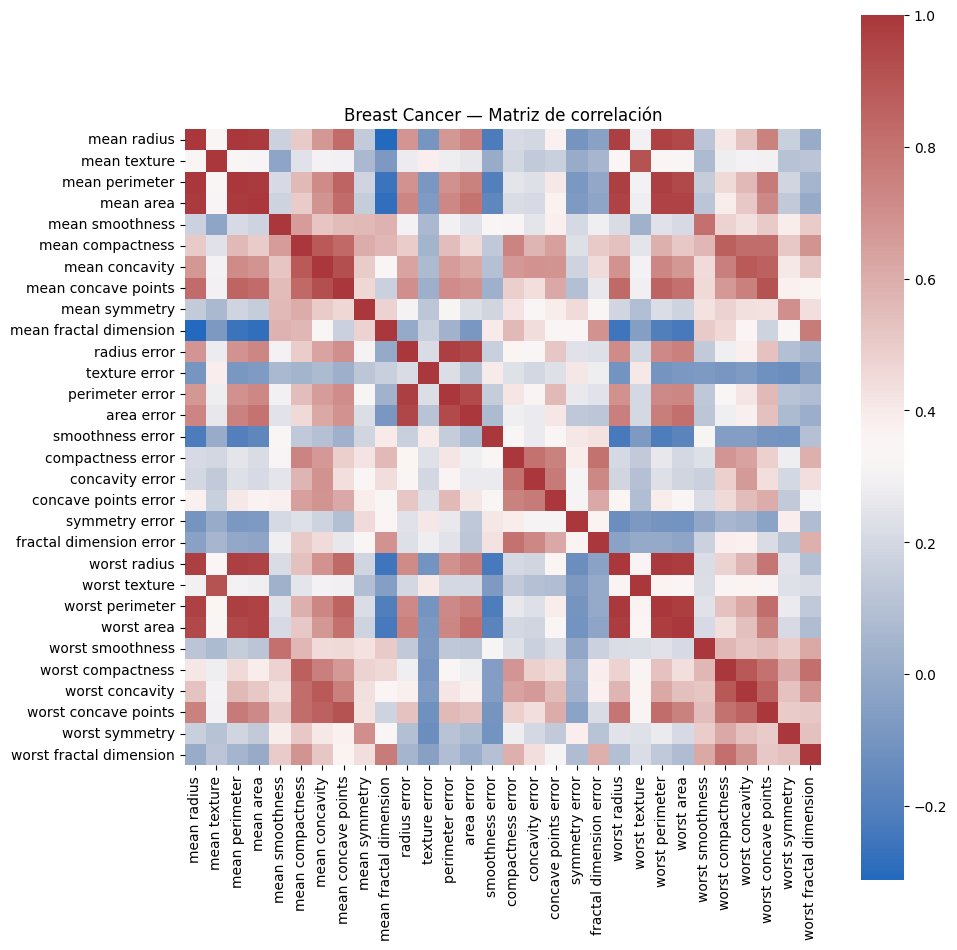

In [43]:
# <CODE> 4. Correlación entre variables
corr = X.corr()
plt.figure(figsize=(10,10))
sns.heatmap(corr, annot=False, fmt=".2f", cmap="vlag", square=True)
plt.title("Breast Cancer — Matriz de correlación")
plt.tight_layout()
plt.show()



#### **Ejercicio 2** 


1. Estandariza las variables predictoras (es importante porque PCA es sensible a la escala). HINT: puedes usar `StandardScaler` de `sklearn.preprocessing`.
2. Aplica PCA reduciendo el dataset a **2 componentes principales**. HINT: usa `PCA` de `sklearn.decomposition`.
3. Visualiza los datos en un scatter plot de PC1 vs PC2, coloreando los puntos por la clase real (0=maligno, 1=benigno).
4. Muestra la **varianza explicada** por cada componente.
5. Identifica las **variables más influyentes** en cada componente principal.
6. Responda:
   * ¿Qué significa que los dos primeros componentes expliquen un alto porcentaje de la varianza?
   * ¿Por qué es útil reducir la dimensionalidad a 2D en este caso?



In [69]:
# <CODE> 1. Estandarización
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [74]:
# <CODE> 2. PCA con 2 componentes
from sklearn.decomposition import PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

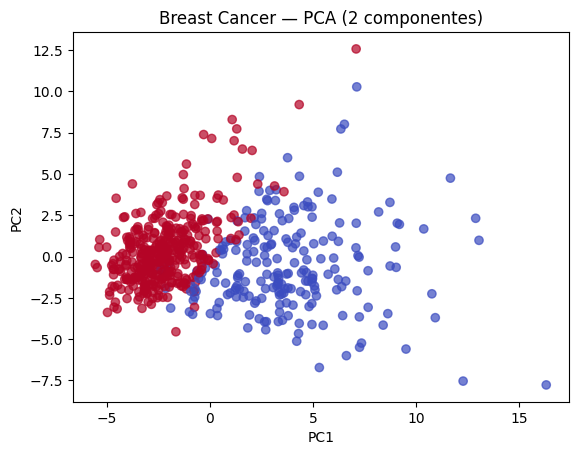

In [75]:
# <CODE> 3. Visualización PC1 vs PC2
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=Y, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Breast Cancer — PCA (2 componentes)")
plt.show()

In [76]:
# <CODE> 4. Varianza explicada
print("Varianza explicada por PC1 y PC2:", pca.explained_variance_ratio_)
print("Varianza acumulada (PC1+PC2):", pca.explained_variance_ratio_.sum())



Varianza explicada por PC1 y PC2: [0.44272026 0.18971182]
Varianza acumulada (PC1+PC2): 0.6324320765155944


In [77]:
# <CODE> 5. Variables más influyentes en PC1 y PC2
import pandas as pd
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=X.columns
)

print("Top variables en PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head())

print("\nTop variables en PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head())






Top variables en PC1:
mean concave points     0.260854
mean concavity          0.258400
worst concave points    0.250886
mean compactness        0.239285
worst perimeter         0.236640
Name: PC1, dtype: float64

Top variables en PC2:
mean fractal dimension     0.366575
fractal dimension error    0.280092
worst fractal dimension    0.275339
mean radius                0.233857
compactness error          0.232716
Name: PC2, dtype: float64


#### **Ejercicio 3** 

1. Aplicar **K-means clustering** con `k=2` sobre los datos clínicos estandarizados (sin usar etiquetas). HINT: usa `KMeans` de `sklearn.cluster`.
2. Visualizar los pacientes en 2D usando una proyección PCA **solo para graficar**.
3. Repetir el proceso aplicando primero **PCA** para reducir las dimensiones a 2 y luego correr **K-means** en ese espacio.
4. Comparar las visualizaciones:
   * ¿Los clusters se ven más definidos después de PCA?
   * ¿Es posible intuir la separación entre tipos de pacientes sin tener las etiquetas?
   * ¿Como se comparan los clusters con las etiquetas reales?


In [91]:
# <CODE> 1. K-means directo en datos originales 
from sklearn.cluster import KMeans
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_raw = kmeans_raw.fit_predict(X_scaled)



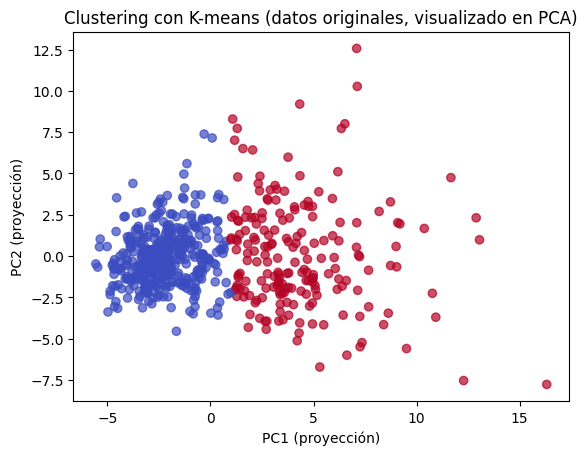

In [92]:
# <CODE> 2. Proyectamos a 2D con PCA solo para visualizar
proj_raw = PCA(n_components=2, random_state=42).fit_transform(X_scaled)

plt.scatter(proj_raw[:, 0], proj_raw[:, 1], c=clusters_raw, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1 (proyección)")
plt.ylabel("PC2 (proyección)")
plt.title("Clustering con K-means (datos originales, visualizado en PCA)")
plt.show()




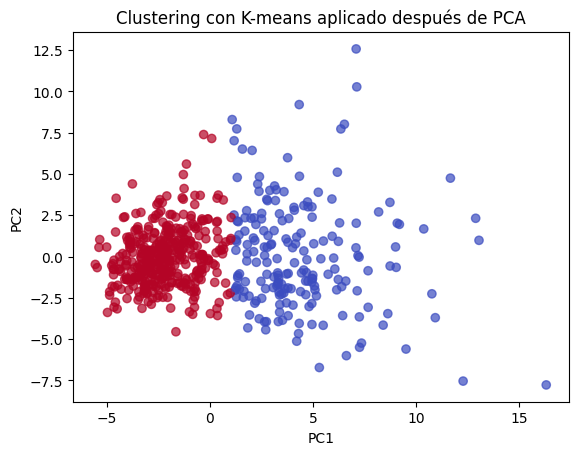

In [93]:
# <CODE> 3. K-means sobre espacio PCA 
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

kmeans_pca = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters_pca = kmeans_pca.fit_predict(X_pca)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters_pca, cmap="coolwarm", alpha=0.7)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clustering con K-means aplicado después de PCA")
plt.show()


